In [3]:
# 1. Mount Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# 2. Install splitting library
!pip install split-folders -q

import os
import shutil
import splitfolders

# 3. Define Paths
drive_path = '/content/drive/MyDrive/archive (27)'
clean_path = '/content/clean_data'
output_dir = '/content/split_dataset'

print("\nPreparing dataset (Extracting ONLY 'Original' images to avoid leakage)...")

# Clean up previous runs if any
if os.path.exists(clean_path):
    shutil.rmtree(clean_path)
os.makedirs(clean_path)

valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp', '.tiff', '.gif')

# 4. Extract and clean data
for class_name in os.listdir(drive_path):
    outer_class_path = os.path.join(drive_path, class_name)

    if os.path.isdir(outer_class_path):
        target_class_path = os.path.join(clean_path, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        img_count = 0
        for root, dirs, files in os.walk(outer_class_path):

            # تخطي أي فولدر يحتوي على كلمة augmented
            if 'augmented' in root.lower():
                continue

            for file in files:
                if file.lower().endswith(valid_extensions):
                    src_file = os.path.join(root, file)
                    # إعادة التسمية برقم لتجنب مسح الصور ذات الأسماء المتشابهة
                    new_file_name = f"{img_count}_{file}"
                    dst_file = os.path.join(target_class_path, new_file_name)

                    shutil.copy(src_file, dst_file)
                    img_count += 1

        print(f" - Moved {img_count} ORIGINAL images for '{class_name}'")

# 5. Split Data
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

print("\nSplitting data into 70% Train, 20% Val, 10% Test...")
splitfolders.ratio(clean_path, output=output_dir,
                   seed=42, ratio=(.7, .2, .1), group_prefix=None)
print("Data splitting completed successfully! Ready for step 2 (Model Building).")

Mounted at /content/drive

Preparing dataset (Extracting ONLY 'Original' images to avoid leakage)...
 - Moved 183 ORIGINAL images for 'Tooth Discoloration'
 - Moved 219 ORIGINAL images for 'Data caries'
 - Moved 1251 ORIGINAL images for 'hypodontia'
 - Moved 1296 ORIGINAL images for 'Calculus'
 - Moved 2349 ORIGINAL images for 'Gingivitis'
 - Moved 265 ORIGINAL images for 'Mouth Ulcer'

Splitting data into 70% Train, 20% Val, 10% Test...


Copying files: 5563 files [00:00, 5965.71 files/s]

Data splitting completed successfully! Ready for step 2 (Model Building).


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# مسارات الداتا اللي اتقسمت
train_dir = '/content/split_dataset/train'
val_dir = '/content/split_dataset/val'
test_dir = '/content/split_dataset/test'

IMAGE_SIZE = (224, 224) # مقاس صور ResNet50
BATCH_SIZE = 32

# عمل Augmentation آمن لداتا التدريب فقط
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# داتا الاختبار والتقييم مش بيتعملها Augmentation (تجهيز فقط)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("Loading Train Data...")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

print("Loading Validation Data...")
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print("Loading Test Data...")
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Loading Train Data...
Found 3892 images belonging to 6 classes.
Loading Validation Data...
Found 1110 images belonging to 6 classes.
Loading Test Data...
Found 561 images belonging to 6 classes.


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

print("Building ResNet50 Model...")

# استدعاء الموديل الأساسي بدون طبقة التصنيف الأخيرة
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# تجميد أوزان الموديل الأساسي عشان منبوظهاش
for layer in base_model.layers:
    layer.trainable = False

# إضافة الطبقات الخاصة بالمشروع بتاعنا
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x) # لمنع الحفظ (Overfitting)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# تجميع الموديل
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model is ready!")
model.summary()

Building ResNet50 Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model is ready!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,639,878 (93.99 MB)

 Trainable params: 1,052,166 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

print("Calculating Class Weights to handle imbalanced data...")

# حساب الأوزان عشان ندي أهمية أكبر للأمراض اللي صورها قليلة
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights_dict = dict(enumerate(class_weights_array))

print("Weights assigned to each class:")
for class_idx, weight in class_weights_dict.items():
    class_name = list(train_generator.class_indices.keys())[class_idx]
    print(f" - {class_name}: {weight:.2f}")

# إعدادات إيقاف التدريب لو الموديل مبقاش يتحسن
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

EPOCHS = 20

print("\nStarting Model Training... (Grab a cup of coffee, this might take a while ☕)")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict  # تطبيق الأوزان السحرية هنا
)

Calculating Class Weights to handle imbalanced data...
Weights assigned to each class:
 - Calculus: 0.72
 - Data caries: 4.24
 - Gingivitis: 0.39
 - Mouth Ulcer: 3.51
 - Tooth Discoloration: 5.07
 - hypodontia: 0.74

Starting Model Training... (Grab a cup of coffee, this might take a while ☕)
Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 94s 638ms/step - accuracy: 0.4990 - loss: 1.5620 - val_accuracy: 0.6045 - val_loss: 0.8185 - learning_rate: 0.0010
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 64s 523ms/step - accuracy: 0.6187 - loss: 0.9313 - val_accuracy: 0.6667 - val_loss: 0.7545 - learning_rate: 0.0010
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 63s 515ms/step - accuracy: 0.6511 - loss: 0.8127 - val_accuracy: 0.6946 - val_loss: 0.6414 - learning_rate: 0.0010
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 502ms/step - accuracy: 0.6475 - loss: 0.7866 - val_accuracy: 0.7108 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.6637 - loss: 0.73

Saving the model to Google Drive...
Model successfully saved at: /content/drive/MyDrive/oral_disease_resnet50.h5 ✅


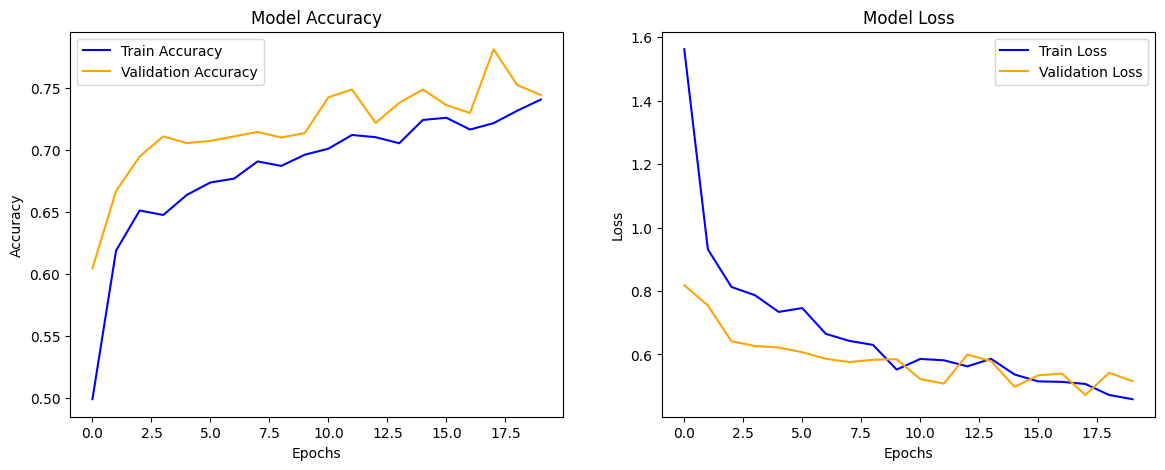


Evaluating on Test Set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 471ms/step - accuracy: 0.7701 - loss: 0.5248
Test Accuracy: 77.01%

Generating Predictions...
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step

Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.73      0.45      0.56       130
        Data caries       0.50      0.57      0.53        23
         Gingivitis       0.74      0.84      0.79       236
        Mouth Ulcer       0.96      0.89      0.92        27
Tooth Discoloration       0.51      0.95      0.67        19
         hypodontia       0.93      0.96      0.95       126

           accuracy                           0.77       561
          macro avg       0.73      0.77      0.73       561
       weighted avg       0.78      0.77      0.76       561



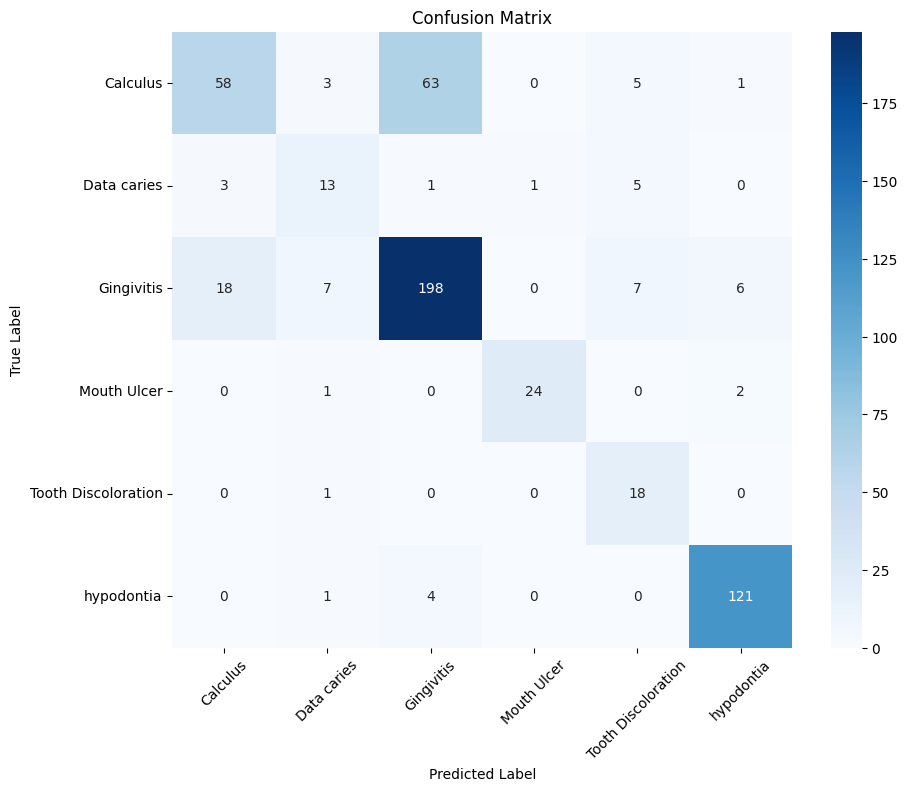

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ==========================================
# 1. حفظ الموديل في Google Drive
# ==========================================
print("Saving the model to Google Drive...")
model_path = '/content/drive/MyDrive/oral_disease_resnet50.h5'
model.save(model_path)
print(f"Model successfully saved at: {model_path} ✅")

# ==========================================
# 2. رسم منحنيات الدقة والخسارة (Accuracy & Loss)
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Accuracy Plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss Plot
ax[1].plot(history.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

# ==========================================
# 3. التقييم النهائي على داتا الاختبار (Test Data)
# ==========================================
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ==========================================
# 4. تقرير التصنيف ومصفوفة الارتباك (Confusion Matrix)
# ==========================================
print("\nGenerating Predictions...")
# بنقفل الـ shuffle عشان الترتيب يفضل مظبوط واحنا بنقارن
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# رسم الـ Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.show()

In [8]:
# ده الكود الصح لموديل TensorFlow/Keras
model_path = '/content/drive/MyDrive/oral_disease_resnet50.h5'
model.save(model_path)